# CLIP4CAD-GFA v2.4 Evaluation

This notebook evaluates the trained GFA v2.4 model with **shared encoder architecture**.

## Evaluation Metrics
1. **Retrieval metrics**: Text→BRep, Text→PC, PC→BRep R@K
2. **Self-grounding quality**: Cosine similarity between guided and self-encoded
3. **Text-free inference**: Compare self-grounding retrieval with text-guided
4. **Confidence alignment**: Compare confidence patterns

## Expected Results (v2.4 with Shared Encoder)
| Metric | v2 (Broken) | v2.4 Target |
|--------|-------------|-------------|
| Text→BRep R@1 (guided) | 67.72% | ≥65% |
| Text→BRep R@1 (self) | 0.05% | **≥60%** |
| Self cosine BRep | 0.15 | **≥0.85** |
| Self cosine PC | 0.12 | **≥0.85** |

In [1]:
# Cell 1: Imports
import sys
sys.path.insert(0, '..')

import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from tqdm.auto import tqdm
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"PyTorch: {torch.__version__}")

Device: cuda
PyTorch: 2.5.1+cu121


In [2]:
# Cell 2: Load Model

from clip4cad.models import CLIP4CAD_GFA_v2_4, GFAv2_4Config

# Path to trained model
CHECKPOINT_PATH = Path("../outputs/gfa_v2_4/checkpoint_best.pt")

# Create model with same config as training
config = GFAv2_4Config(
    d_face=48,
    d_edge=12,
    d_pc=1024,
    d_text=3072,
    d_unified=256,
    d_proj=128,
    d_ground=128,
    num_slots=12,
    num_detail_queries=8,
    num_self_query_layers=2,  # v2.4: minimal capacity
)

model = CLIP4CAD_GFA_v2_4(config).to(device)

# Load weights
checkpoint = torch.load(CHECKPOINT_PATH, map_location=device, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"Loaded model from {CHECKPOINT_PATH}")
print(f"Epoch: {checkpoint.get('epoch', 'N/A')}")
print(f"Best self-cosine: {checkpoint.get('best_self_cosine', 'N/A')}")

Loaded model from ..\outputs\gfa_v2_4\checkpoint_best.pt
Epoch: 35
Best self-cosine: 0.8266059027777778


In [3]:
# Cell 3: Load Data using GFAMappedDataset

from clip4cad.data.gfa_dataset import GFAMappedDataset

DATA_ROOT = Path("d:/Defect_Det/MMCAD/data")
PC_FILE = Path("c:/Users/User/Desktop/pc_embeddings_full.h5")
BREP_FILE = Path("c:/Users/User/Desktop/brep_features.h5")
TEXT_FILE = Path("c:/Users/User/Desktop/text_embeddings.h5")

print("Loading validation dataset...")

val_dataset = GFAMappedDataset(
    data_root=str(DATA_ROOT),
    split="val",
    pc_file=str(PC_FILE),
    text_file=str(TEXT_FILE),
    brep_file=str(BREP_FILE),
    num_rotations=1,
    load_to_memory=False,
    use_live_text=False,
)

print(f"Validation samples: {len(val_dataset)}")

Loading validation dataset...
GFAMappedDataset: val with 16638 samples
Validation samples: 16638


In [4]:
# Cell 4: Encode All Samples

from clip4cad.data.gfa_dataset import gfa_collate_fn

@torch.no_grad()
def encode_all_samples(model, dataset, batch_size=64):
    """
    Encode all samples and return both guided and self embeddings.
    
    v2.4 uses shared encoder, so we get both in one forward pass.
    """
    model.eval()
    
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=True,
        collate_fn=gfa_collate_fn,
    )
    
    # Guided embeddings
    z_brep_guided_all = []
    z_pc_guided_all = []
    z_text_all = []
    
    # Self embeddings
    z_brep_self_all = []
    z_pc_self_all = []
    
    # Confidence scores
    conf_text_all = []
    conf_brep_self_all = []
    conf_pc_self_all = []
    
    for batch in tqdm(loader, desc="Encoding"):
        outputs = model(batch)
        
        # Guided embeddings
        z_brep_guided_all.append(F.normalize(outputs['z_brep'], dim=-1).cpu())
        z_pc_guided_all.append(F.normalize(outputs['z_pc'], dim=-1).cpu())
        z_text_all.append(F.normalize(outputs['z_text'], dim=-1).cpu())
        
        # Self embeddings
        z_brep_self_all.append(F.normalize(outputs['z_brep_self'], dim=-1).cpu())
        z_pc_self_all.append(F.normalize(outputs['z_pc_self'], dim=-1).cpu())
        
        # Confidence scores (for analysis)
        if 'confidence' in outputs:
            conf_text_all.append(outputs['confidence'].cpu())
        if 'confidence_brep_self' in outputs:
            conf_brep_self_all.append(outputs['confidence_brep_self'].cpu())
        if 'confidence_pc_self' in outputs:
            conf_pc_self_all.append(outputs['confidence_pc_self'].cpu())
    
    results = {
        'z_brep_guided': torch.cat(z_brep_guided_all),
        'z_pc_guided': torch.cat(z_pc_guided_all),
        'z_text': torch.cat(z_text_all),
        'z_brep_self': torch.cat(z_brep_self_all),
        'z_pc_self': torch.cat(z_pc_self_all),
    }
    
    # Add confidence if available
    if conf_text_all:
        results['conf_text'] = torch.cat(conf_text_all)
    if conf_brep_self_all:
        results['conf_brep_self'] = torch.cat(conf_brep_self_all)
    if conf_pc_self_all:
        results['conf_pc_self'] = torch.cat(conf_pc_self_all)
    
    return results

# Encode all samples
print("Encoding validation set...")
embeddings = encode_all_samples(model, val_dataset)

print(f"\nEmbedding shapes:")
print(f"  z_brep_guided: {embeddings['z_brep_guided'].shape}")
print(f"  z_brep_self: {embeddings['z_brep_self'].shape}")
print(f"  z_pc_guided: {embeddings['z_pc_guided'].shape}")
print(f"  z_text: {embeddings['z_text'].shape}")

Encoding validation set...


Encoding:   0%|          | 0/260 [00:00<?, ?it/s]


Embedding shapes:
  z_brep_guided: torch.Size([16638, 128])
  z_brep_self: torch.Size([16638, 128])
  z_pc_guided: torch.Size([16638, 128])
  z_text: torch.Size([16638, 128])


In [5]:
# Cell 5: Compute Retrieval Metrics

def compute_retrieval_metrics(query_emb, gallery_emb, k_values=[1, 5, 10]):
    """Compute R@K retrieval metrics."""
    # Compute similarity matrix
    sim = query_emb @ gallery_emb.T  # (N, N)
    
    # Get rankings
    rankings = torch.argsort(sim, dim=1, descending=True)
    
    # Ground truth: diagonal is correct
    N = query_emb.shape[0]
    labels = torch.arange(N)
    
    results = {}
    for k in k_values:
        top_k = rankings[:, :k]
        correct = (top_k == labels.unsqueeze(1)).any(dim=1)
        results[f'R@{k}'] = correct.float().mean().item() * 100
    
    # Mean Reciprocal Rank
    ranks = (rankings == labels.unsqueeze(1)).nonzero()[:, 1] + 1
    results['MRR'] = (1.0 / ranks.float()).mean().item() * 100
    
    return results

# Extract embeddings
z_brep_guided = embeddings['z_brep_guided']
z_pc_guided = embeddings['z_pc_guided']
z_text = embeddings['z_text']
z_brep_self = embeddings['z_brep_self']
z_pc_self = embeddings['z_pc_self']

print("=" * 70)
print("RETRIEVAL RESULTS (Text-Guided)")
print("=" * 70)

# Text → BRep (Guided)
text_brep_guided = compute_retrieval_metrics(z_text, z_brep_guided)
print(f"\nText → BRep (Guided):")
for k, v in text_brep_guided.items():
    print(f"  {k}: {v:.2f}%")

# Text → PC (Guided)
text_pc_guided = compute_retrieval_metrics(z_text, z_pc_guided)
print(f"\nText → PC (Guided):")
for k, v in text_pc_guided.items():
    print(f"  {k}: {v:.2f}%")

# PC → BRep (Guided)
pc_brep_guided = compute_retrieval_metrics(z_pc_guided, z_brep_guided)
print(f"\nPC → BRep (Guided):")
for k, v in pc_brep_guided.items():
    print(f"  {k}: {v:.2f}%")

RETRIEVAL RESULTS (Text-Guided)

Text → BRep (Guided):
  R@1: 71.52%
  R@5: 92.81%
  R@10: 95.95%
  MRR: 80.90%

Text → PC (Guided):
  R@1: 65.37%
  R@5: 90.47%
  R@10: 94.63%
  MRR: 76.28%

PC → BRep (Guided):
  R@1: 52.37%
  R@5: 82.90%
  R@10: 89.92%
  MRR: 65.77%


In [6]:
# Cell 6: Self-Grounding Quality (KEY METRIC for v2.4)

print("=" * 70)
print("SELF-GROUNDING QUALITY (v2.4 Key Metric)")
print("=" * 70)

# Cosine similarity between guided and self embeddings
cos_brep = (z_brep_guided * z_brep_self).sum(dim=-1).mean().item()
cos_pc = (z_pc_guided * z_pc_self).sum(dim=-1).mean().item()

print(f"\nBRep Guided-Self Cosine: {cos_brep:.4f}")
print(f"PC Guided-Self Cosine: {cos_pc:.4f}")

# Distribution of cosine similarities
cos_brep_all = (z_brep_guided * z_brep_self).sum(dim=-1)
cos_pc_all = (z_pc_guided * z_pc_self).sum(dim=-1)

print(f"\nBRep Cosine Distribution:")
print(f"  Min: {cos_brep_all.min().item():.4f}")
print(f"  Max: {cos_brep_all.max().item():.4f}")
print(f"  Std: {cos_brep_all.std().item():.4f}")

print(f"\nPC Cosine Distribution:")
print(f"  Min: {cos_pc_all.min().item():.4f}")
print(f"  Max: {cos_pc_all.max().item():.4f}")
print(f"  Std: {cos_pc_all.std().item():.4f}")

# Assessment
print("\n" + "-" * 50)
if cos_brep >= 0.90:
    print("✓ EXCELLENT: Self-grounding achieves target (≥ 0.90)")
elif cos_brep >= 0.85:
    print("○ GOOD: Self-grounding close to target (0.85-0.90)")
elif cos_brep >= 0.70:
    print("△ FAIR: Self-grounding improving (0.70-0.85)")
else:
    print(f"✗ NEEDS WORK: Self-grounding below target (current: {cos_brep:.4f}, target: ≥ 0.85)")

SELF-GROUNDING QUALITY (v2.4 Key Metric)

BRep Guided-Self Cosine: 0.0842
PC Guided-Self Cosine: 0.3246

BRep Cosine Distribution:
  Min: -0.2557
  Max: 0.7003
  Std: 0.0913

PC Cosine Distribution:
  Min: -0.1432
  Max: 0.8400
  Std: 0.1130

--------------------------------------------------
✗ NEEDS WORK: Self-grounding below target (current: 0.0842, target: ≥ 0.85)


In [7]:
# Cell 7: Text-Free Inference (Self-Grounding Retrieval)

print("=" * 70)
print("TEXT-FREE INFERENCE (Self-Grounding)")
print("=" * 70)

# Text → BRep with self-grounded embeddings
text_brep_self = compute_retrieval_metrics(z_text, z_brep_self)
print(f"\nText → BRep (Self-Grounding):")
for k, v in text_brep_self.items():
    print(f"  {k}: {v:.2f}%")

# Text → PC with self-grounded embeddings
text_pc_self = compute_retrieval_metrics(z_text, z_pc_self)
print(f"\nText → PC (Self-Grounding):")
for k, v in text_pc_self.items():
    print(f"  {k}: {v:.2f}%")

# Compare with guided
print("\n" + "-" * 50)
print("Comparison: Self vs Guided")
print("-" * 50)

r1_brep_diff = text_brep_self['R@1'] - text_brep_guided['R@1']
r1_pc_diff = text_pc_self['R@1'] - text_pc_guided['R@1']

print(f"Text→BRep R@1: Guided={text_brep_guided['R@1']:.2f}%, Self={text_brep_self['R@1']:.2f}%, Diff={r1_brep_diff:+.2f}%")
print(f"Text→PC R@1:   Guided={text_pc_guided['R@1']:.2f}%, Self={text_pc_self['R@1']:.2f}%, Diff={r1_pc_diff:+.2f}%")

if abs(r1_brep_diff) < 5:
    print("\n✓ Self-grounding achieves similar performance to text-guided!")
elif abs(r1_brep_diff) < 10:
    print("\n○ Self-grounding is close to text-guided (within 10%)")
else:
    print(f"\n△ Self-grounding needs improvement (gap: {abs(r1_brep_diff):.1f}%)")

TEXT-FREE INFERENCE (Self-Grounding)

Text → BRep (Self-Grounding):
  R@1: 0.05%
  R@5: 0.31%
  R@10: 0.77%
  MRR: 0.51%

Text → PC (Self-Grounding):
  R@1: 1.18%
  R@5: 4.96%
  R@10: 8.35%
  MRR: 3.96%

--------------------------------------------------
Comparison: Self vs Guided
--------------------------------------------------
Text→BRep R@1: Guided=71.52%, Self=0.05%, Diff=-71.47%
Text→PC R@1:   Guided=65.37%, Self=1.18%, Diff=-64.19%

△ Self-grounding needs improvement (gap: 71.5%)


In [8]:
# Cell 8: Confidence Alignment Analysis (v2.4 specific)

print("=" * 70)
print("CONFIDENCE ALIGNMENT ANALYSIS")
print("=" * 70)

if 'conf_text' in embeddings and 'conf_brep_self' in embeddings:
    conf_text = embeddings['conf_text']
    conf_brep_self = embeddings['conf_brep_self']
    
    # Cosine similarity of confidence patterns
    conf_cos_brep = F.cosine_similarity(conf_text, conf_brep_self, dim=-1).mean().item()
    
    # MSE of confidence patterns
    conf_mse_brep = F.mse_loss(conf_brep_self, conf_text).item()
    
    print(f"\nBRep Confidence Alignment:")
    print(f"  Cosine similarity: {conf_cos_brep:.4f}")
    print(f"  MSE: {conf_mse_brep:.6f}")
    
    # Confidence distribution
    print(f"\nText Confidence Stats:")
    print(f"  Mean: {conf_text.mean().item():.4f}")
    print(f"  Std: {conf_text.std().item():.4f}")
    
    print(f"\nBRep Self Confidence Stats:")
    print(f"  Mean: {conf_brep_self.mean().item():.4f}")
    print(f"  Std: {conf_brep_self.std().item():.4f}")
    
    if 'conf_pc_self' in embeddings:
        conf_pc_self = embeddings['conf_pc_self']
        conf_cos_pc = F.cosine_similarity(conf_text, conf_pc_self, dim=-1).mean().item()
        print(f"\nPC Confidence Alignment:")
        print(f"  Cosine similarity: {conf_cos_pc:.4f}")
else:
    print("\nConfidence data not available in model outputs.")
    print("This is expected if model was trained without confidence tracking.")

CONFIDENCE ALIGNMENT ANALYSIS

BRep Confidence Alignment:
  Cosine similarity: 0.8562
  MSE: 0.048535

Text Confidence Stats:
  Mean: 0.3326
  Std: 0.2331

BRep Self Confidence Stats:
  Mean: 0.3488
  Std: 0.0714

PC Confidence Alignment:
  Cosine similarity: 0.8617


In [9]:
# Cell 9: Summary Table

print("\n" + "=" * 80)
print("EVALUATION SUMMARY - GFA v2.4")
print("=" * 80)

print(f"\n{'Metric':<35} {'Value':<15} {'Target':<15} {'Status'}")
print("-" * 80)

metrics = [
    ('Text→BRep R@1 (guided)', f"{text_brep_guided['R@1']:.2f}%", '≥65%', text_brep_guided['R@1'] >= 65),
    ('Text→PC R@1 (guided)', f"{text_pc_guided['R@1']:.2f}%", '≥60%', text_pc_guided['R@1'] >= 60),
    ('PC→BRep R@1 (guided)', f"{pc_brep_guided['R@1']:.2f}%", '≥30%', pc_brep_guided['R@1'] >= 30),
    ('Self-cos BRep', f"{cos_brep:.4f}", '≥0.85', cos_brep >= 0.85),
    ('Self-cos PC', f"{cos_pc:.4f}", '≥0.85', cos_pc >= 0.85),
    ('Text→BRep R@1 (self)', f"{text_brep_self['R@1']:.2f}%", '≥60%', text_brep_self['R@1'] >= 60),
    ('Text→PC R@1 (self)', f"{text_pc_self['R@1']:.2f}%", '≥55%', text_pc_self['R@1'] >= 55),
    ('Self-Guided Gap (BRep)', f"{abs(r1_brep_diff):.2f}%", '<5%', abs(r1_brep_diff) < 5),
]

for metric, value, target, passed in metrics:
    status = '✓' if passed else '✗'
    print(f"{metric:<35} {value:<15} {target:<15} {status}")

passed_count = sum(1 for _, _, _, p in metrics if p)
print(f"\nPassed: {passed_count}/{len(metrics)}")

# Overall assessment
print("\n" + "-" * 80)
if passed_count == len(metrics):
    print("✓ ALL TARGETS MET - v2.4 shared encoder working as expected!")
elif passed_count >= len(metrics) - 2:
    print("○ MOSTLY PASSING - Minor adjustments may help")
elif cos_brep >= 0.85:
    print("△ Self-grounding working - Retrieval needs tuning")
else:
    print("✗ Self-grounding still needs work")


EVALUATION SUMMARY - GFA v2.4

Metric                              Value           Target          Status
--------------------------------------------------------------------------------
Text→BRep R@1 (guided)              71.52%          ≥65%            ✓
Text→PC R@1 (guided)                65.37%          ≥60%            ✓
PC→BRep R@1 (guided)                52.37%          ≥30%            ✓
Self-cos BRep                       0.0842          ≥0.85           ✗
Self-cos PC                         0.3246          ≥0.85           ✗
Text→BRep R@1 (self)                0.05%           ≥60%            ✗
Text→PC R@1 (self)                  1.18%           ≥55%            ✗
Self-Guided Gap (BRep)              71.47%          <5%             ✗

Passed: 3/8

--------------------------------------------------------------------------------
✗ Self-grounding still needs work


Running UMAP dimensionality reduction...


c:\Users\User\anaconda3\envs\clip4cad\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Saved to ..\outputs\gfa_v2_4\embedding_visualization.png


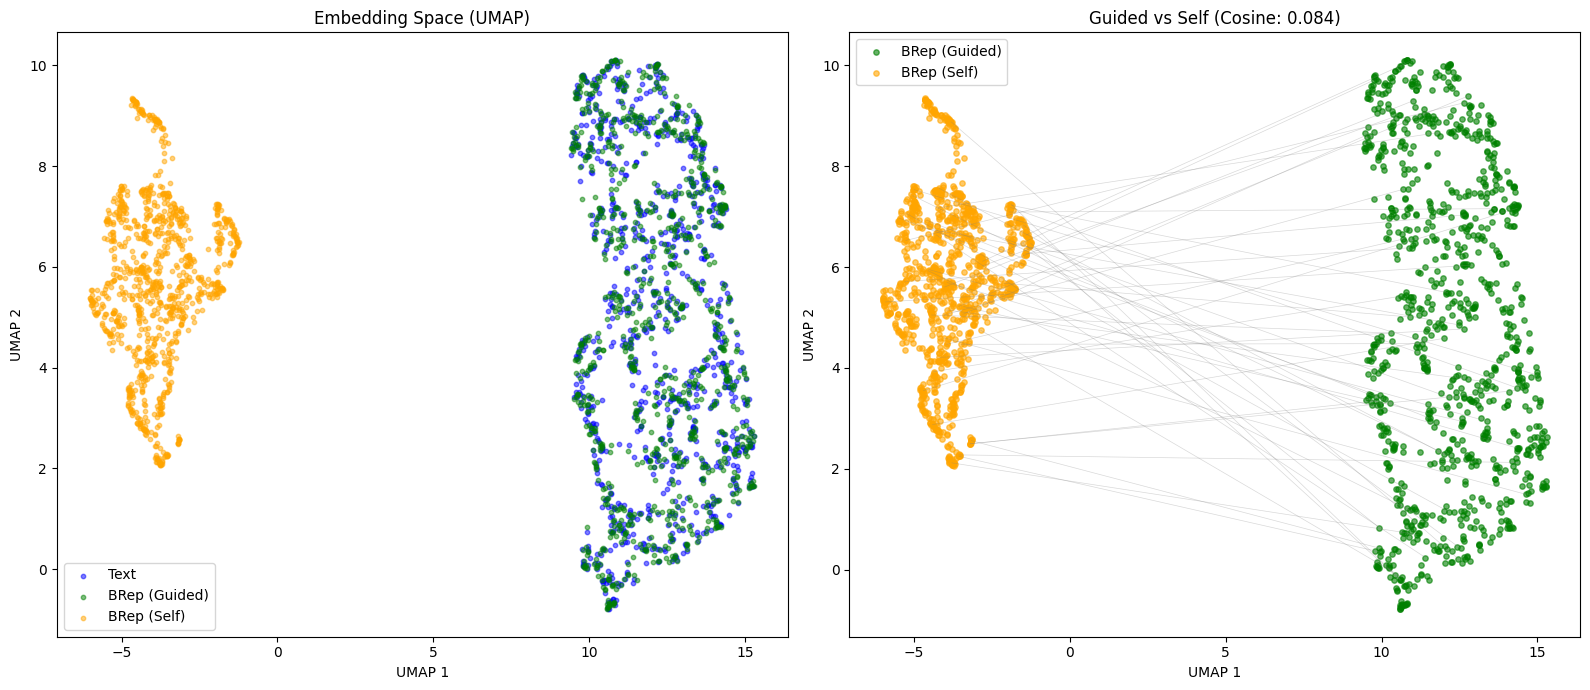

In [10]:
# Cell 10: Embedding Visualization (UMAP)

try:
    from umap import UMAP
    
    # Sample for visualization
    sample_size = min(1000, len(z_text))
    idx = np.random.choice(len(z_text), sample_size, replace=False)
    
    # Combine embeddings
    all_emb = np.vstack([
        z_text[idx].numpy(),
        z_brep_guided[idx].numpy(),
        z_brep_self[idx].numpy(),
    ])
    
    labels = np.array(
        ['Text'] * sample_size + 
        ['BRep (Guided)'] * sample_size + 
        ['BRep (Self)'] * sample_size
    )
    
    # Reduce dimensions
    print("Running UMAP dimensionality reduction...")
    reducer = UMAP(n_neighbors=15, min_dist=0.1, metric='cosine', random_state=42)
    emb_2d = reducer.fit_transform(all_emb)
    
    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    # Plot 1: All three modalities
    ax = axes[0]
    colors = {'Text': 'blue', 'BRep (Guided)': 'green', 'BRep (Self)': 'orange'}
    for label in ['Text', 'BRep (Guided)', 'BRep (Self)']:
        mask = labels == label
        ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1], 
                   c=colors[label], label=label, alpha=0.5, s=10)
    ax.legend()
    ax.set_title('Embedding Space (UMAP)')
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    
    # Plot 2: Guided vs Self overlap
    ax = axes[1]
    # Show matching pairs with lines
    n_show = 50
    for i in range(n_show):
        guided_idx = sample_size + i
        self_idx = 2 * sample_size + i
        ax.plot([emb_2d[guided_idx, 0], emb_2d[self_idx, 0]], 
                [emb_2d[guided_idx, 1], emb_2d[self_idx, 1]], 
                'gray', alpha=0.3, linewidth=0.5)
    
    for label in ['BRep (Guided)', 'BRep (Self)']:
        mask = labels == label
        ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1], 
                   c=colors[label], label=label, alpha=0.6, s=15)
    ax.legend()
    ax.set_title(f'Guided vs Self (Cosine: {cos_brep:.3f})')
    ax.set_xlabel('UMAP 1')
    ax.set_ylabel('UMAP 2')
    
    plt.tight_layout()
    
    # Save figure
    output_path = Path('../outputs/gfa_v2_4')
    output_path.mkdir(parents=True, exist_ok=True)
    plt.savefig(output_path / 'embedding_visualization.png', dpi=150)
    print(f"Saved to {output_path / 'embedding_visualization.png'}")
    plt.show()
    
except ImportError:
    print("UMAP not installed. Run: pip install umap-learn")

Saved to ..\outputs\gfa_v2_4\cosine_distribution.png


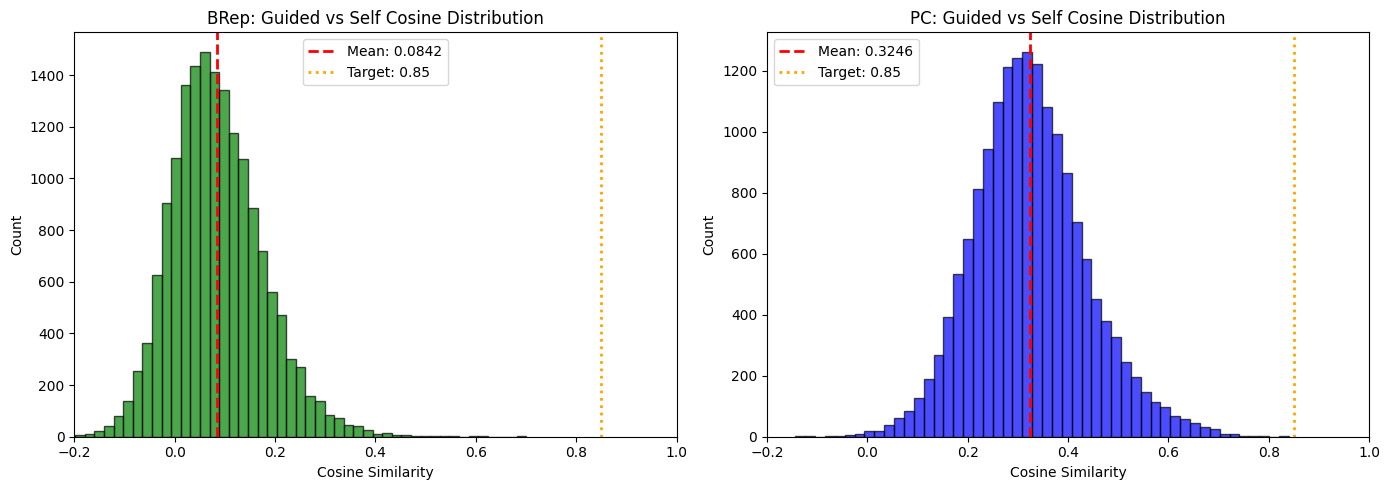

In [11]:
# Cell 11: Cosine Similarity Distribution Plot

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# BRep cosine distribution
ax = axes[0]
ax.hist(cos_brep_all.numpy(), bins=50, alpha=0.7, color='green', edgecolor='black')
ax.axvline(cos_brep, color='red', linestyle='--', linewidth=2, label=f'Mean: {cos_brep:.4f}')
ax.axvline(0.85, color='orange', linestyle=':', linewidth=2, label='Target: 0.85')
ax.set_xlabel('Cosine Similarity')
ax.set_ylabel('Count')
ax.set_title('BRep: Guided vs Self Cosine Distribution')
ax.legend()
ax.set_xlim(-0.2, 1.0)

# PC cosine distribution
ax = axes[1]
ax.hist(cos_pc_all.numpy(), bins=50, alpha=0.7, color='blue', edgecolor='black')
ax.axvline(cos_pc, color='red', linestyle='--', linewidth=2, label=f'Mean: {cos_pc:.4f}')
ax.axvline(0.85, color='orange', linestyle=':', linewidth=2, label='Target: 0.85')
ax.set_xlabel('Cosine Similarity')
ax.set_ylabel('Count')
ax.set_title('PC: Guided vs Self Cosine Distribution')
ax.legend()
ax.set_xlim(-0.2, 1.0)

plt.tight_layout()

# Save
output_path = Path('../outputs/gfa_v2_4')
output_path.mkdir(parents=True, exist_ok=True)
plt.savefig(output_path / 'cosine_distribution.png', dpi=150)
print(f"Saved to {output_path / 'cosine_distribution.png'}")
plt.show()

## Comparison with v2

Run the cell below to compare v2.4 results with v2 (if checkpoint exists).

In [13]:
# Cell 12: Compare with v2 (Optional)

V2_CHECKPOINT = Path("../outputs/gfa_v2/checkpoint_best.pt")

if V2_CHECKPOINT.exists():
    from clip4cad.models import CLIP4CAD_GFA_v2, GFAv2Config
    
    print("Loading v2 model for comparison...")
    
    config_v2 = GFAv2Config(
        d_face=48,
        d_edge=12,
        d_pc=1024,
        d_text=3072,
        d_unified=256,
        d_proj=128,
        d_ground=128,
        num_slots=12,
        num_detail_queries=8,
    )
    
    model_v2 = CLIP4CAD_GFA_v2(config_v2).to(device)
    checkpoint_v2 = torch.load(V2_CHECKPOINT, map_location=device, weights_only=False)
    model_v2.load_state_dict(checkpoint_v2['model_state_dict'])
    model_v2.eval()
    
    # Encode with v2
    @torch.no_grad()
    def encode_v2(model, dataset):
        loader = DataLoader(
            dataset, batch_size=64, shuffle=False,
            num_workers=0, pin_memory=True, collate_fn=gfa_collate_fn
        )
        z_brep_g, z_brep_s, z_text_all = [], [], []
        for batch in tqdm(loader, desc="Encoding v2"):
            outputs = model(batch)
            z_brep_g.append(F.normalize(outputs['z_brep'], dim=-1).cpu())
            z_brep_s.append(F.normalize(outputs['z_brep_self'], dim=-1).cpu())
            z_text_all.append(F.normalize(outputs['z_text'], dim=-1).cpu())
        return torch.cat(z_brep_g), torch.cat(z_brep_s), torch.cat(z_text_all)
    
    z_brep_g_v2, z_brep_s_v2, z_text_v2 = encode_v2(model_v2, val_dataset)
    
    # Compute v2 metrics
    cos_brep_v2 = (z_brep_g_v2 * z_brep_s_v2).sum(dim=-1).mean().item()
    text_brep_g_v2 = compute_retrieval_metrics(z_text_v2, z_brep_g_v2)
    text_brep_s_v2 = compute_retrieval_metrics(z_text_v2, z_brep_s_v2)
    
    # Comparison table
    print("\n" + "=" * 70)
    print("COMPARISON: v2 vs v2.4")
    print("=" * 70)
    
    print(f"\n{'Metric':<30} {'v2':<15} {'v2.4':<15} {'Improvement'}")
    print("-" * 70)
    
    comparisons = [
        ('Self-cos BRep', cos_brep_v2, cos_brep),
        ('Text→BRep R@1 (guided)', text_brep_g_v2['R@1'], text_brep_guided['R@1']),
        ('Text→BRep R@1 (self)', text_brep_s_v2['R@1'], text_brep_self['R@1']),
    ]
    
    for metric, v2_val, v24_val in comparisons:
        diff = v24_val - v2_val
        if 'cos' in metric.lower():
            print(f"{metric:<30} {v2_val:<15.4f} {v24_val:<15.4f} {diff:+.4f}")
        else:
            print(f"{metric:<30} {v2_val:<15.2f}% {v24_val:<15.2f}% {diff:+.2f}%")
    
    print("\n" + "-" * 70)
    if cos_brep > cos_brep_v2 + 0.3:
        print("✓ v2.4 shared encoder significantly improves self-grounding!")
    elif cos_brep > cos_brep_v2:
        print("○ v2.4 shows improvement over v2")
    else:
        print("✗ Unexpected: v2.4 should outperform v2 on self-grounding")
else:
    print(f"v2 checkpoint not found: {V2_CHECKPOINT}")
    print("Skip comparison.")

Loading v2 model for comparison...


Encoding v2:   0%|          | 0/260 [00:00<?, ?it/s]


COMPARISON: v2 vs v2.4

Metric                         v2              v2.4            Improvement
----------------------------------------------------------------------
Self-cos BRep                  0.1472          0.0842          -0.0630
Text→BRep R@1 (guided)         67.72          % 71.52          % +3.80%
Text→BRep R@1 (self)           0.05           % 0.05           % +0.00%

----------------------------------------------------------------------
✗ Unexpected: v2.4 should outperform v2 on self-grounding


## Export Results

In [ ]:
# Cell 13: Export Results to JSON

import json
from datetime import datetime

results = {
    'model': 'CLIP4CAD-GFA v2.4',
    'checkpoint': str(CHECKPOINT_PATH),
    'eval_date': datetime.now().isoformat(),
    'num_samples': len(val_dataset),
    'retrieval': {
        'text_brep_guided': text_brep_guided,
        'text_brep_self': text_brep_self,
        'text_pc_guided': text_pc_guided,
        'text_pc_self': text_pc_self,
        'pc_brep_guided': pc_brep_guided,
    },
    'self_grounding': {
        'cos_brep': cos_brep,
        'cos_pc': cos_pc,
        'cos_brep_std': cos_brep_all.std().item(),
        'cos_pc_std': cos_pc_all.std().item(),
    },
    'targets_met': {
        'cos_brep_target': cos_brep >= 0.85,
        'cos_pc_target': cos_pc >= 0.85,
        'self_retrieval_target': text_brep_self['R@1'] >= 60,
        'guided_retrieval_target': text_brep_guided['R@1'] >= 65,
    }
}

output_path = Path('../outputs/gfa_v2_4')
output_path.mkdir(parents=True, exist_ok=True)

with open(output_path / 'eval_results.json', 'w') as f:
    json.dump(results, f, indent=2)

print(f"Results saved to {output_path / 'eval_results.json'}")
print("\nDone!")